# Heart Failure Prediction using Machine Learning and Deep Learning

## 1. Problem Statement

The objective of this project is to predict whether a patient is at risk of death due to heart failure using clinical data.

## 2. Importing Libraries

In [68]:
import pandas as pd
import numpy as np

## 3. Data Loading

In [1]:
df = pd.read_csv("../data/heart_failure_clinical_records_dataset.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


## 4. Exploratory Data Analysis (EDA)

In [70]:
# Checking dataset structure and data types
df.info

<bound method DataFrame.info of       age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0    75.0        0                       582         0                 20   
1    55.0        0                      7861         0                 38   
2    65.0        0                       146         0                 20   
3    50.0        1                       111         0                 20   
4    65.0        1                       160         1                 20   
..    ...      ...                       ...       ...                ...   
294  62.0        0                        61         1                 38   
295  55.0        0                      1820         0                 38   
296  45.0        0                      2060         1                 60   
297  45.0        0                      2413         0                 38   
298  50.0        0                       196         0                 45   

     high_blood_pressure  platelets  serum_

In [3]:
df.shape

(299, 13)

In [71]:
# Summary statistics of features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


In [72]:
df["DEATH_EVENT"].value_counts()

##1 for the death and 0 for survived 

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

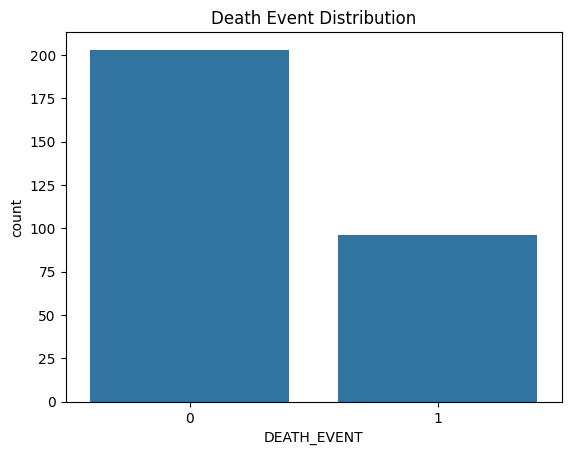

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df["DEATH_EVENT"])
plt.title("Death Event Distribution")
plt.show()

### Observation:
- Dataset is slightly imbalanced
- More survival cases than death cases

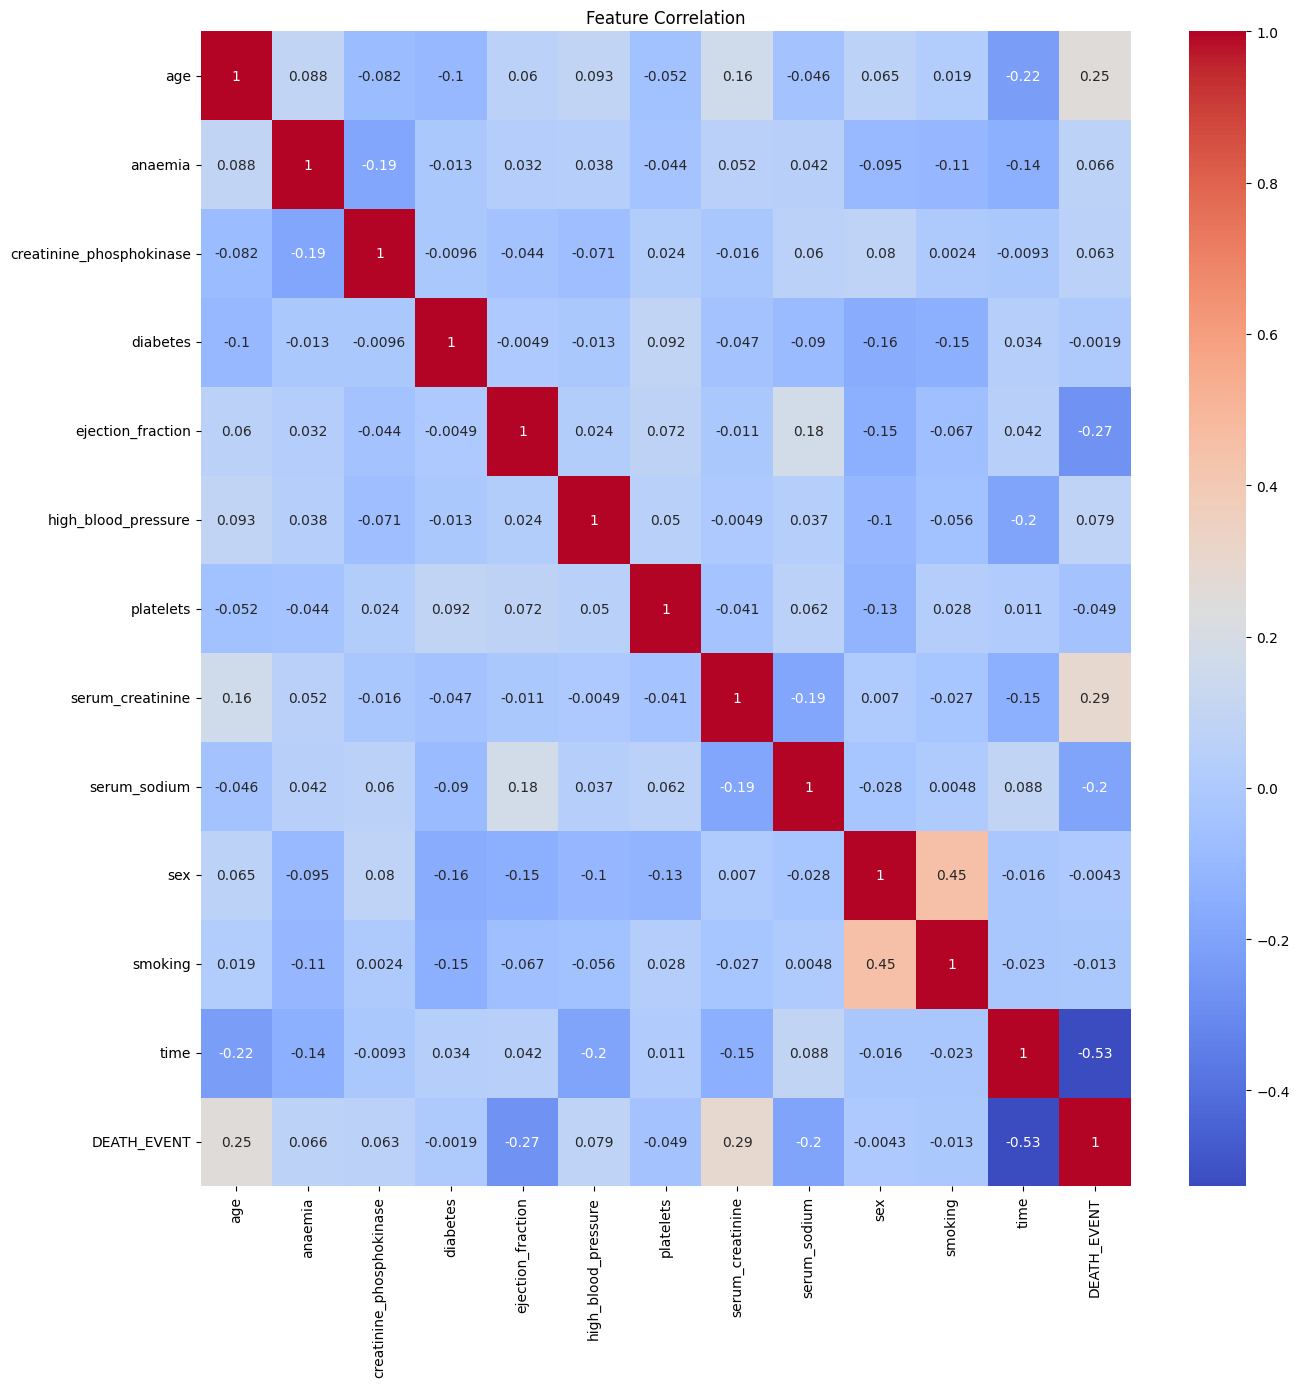

In [8]:
plt.figure(figsize=(15,15))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")
plt.show()

### Observation:
- No strong correlation between features
- No feature needs to be removed

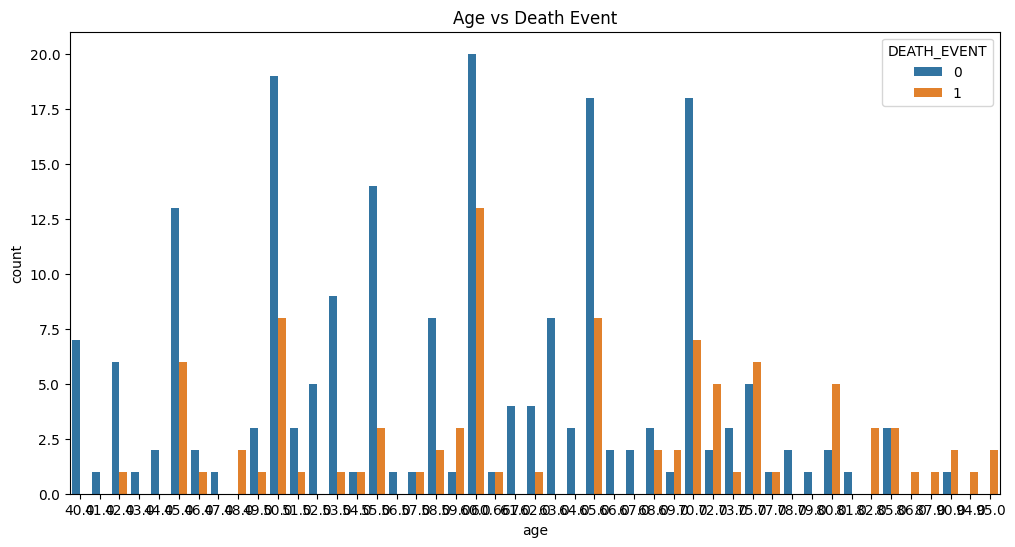

In [9]:
plt.figure(figsize=(12,6))

sns.countplot(
    x=df["age"],
    hue=df["DEATH_EVENT"]
)

plt.title("Age vs Death Event")
plt.show()

In [13]:
features = [
    'age',
    'ejection_fraction',
    'platelets',
    'serum_creatinine',
    'serum_sodium',
    'time'
]

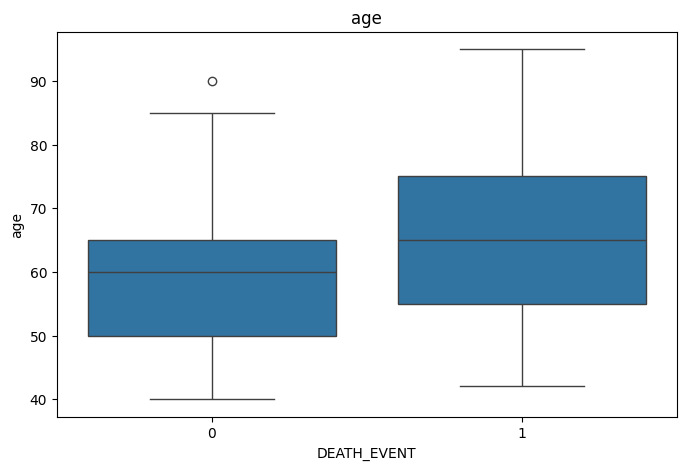

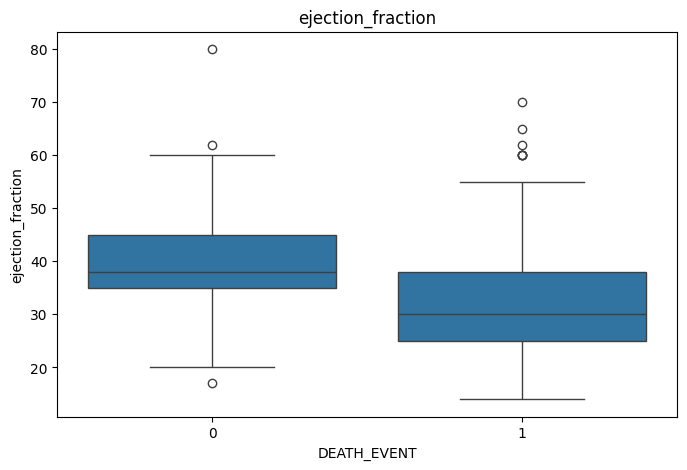

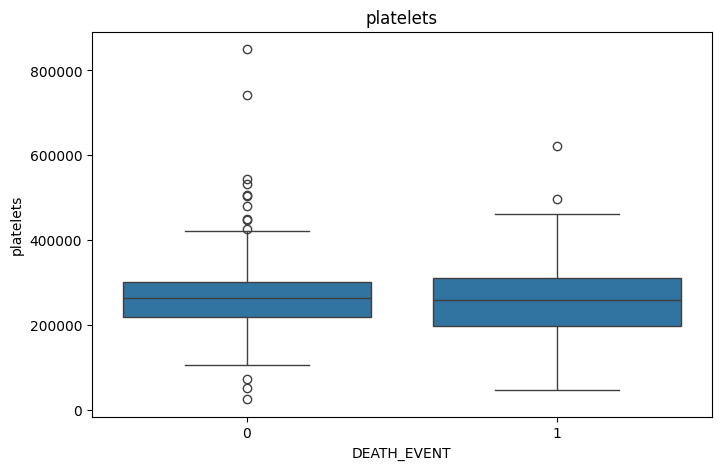

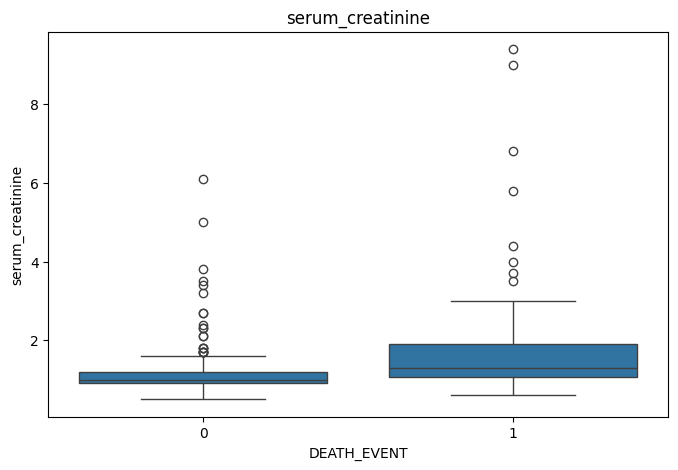

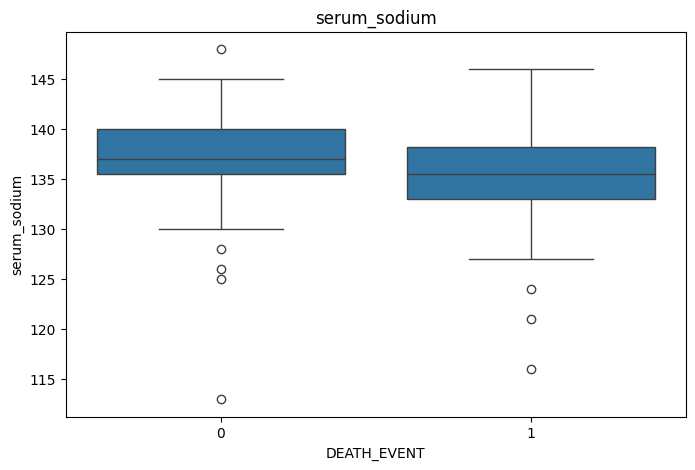

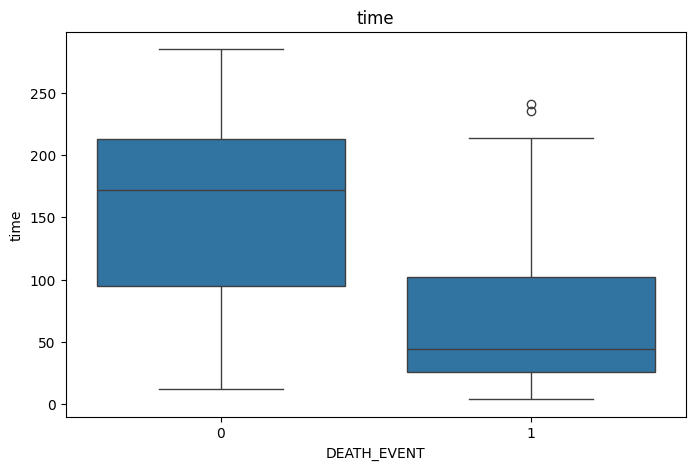

In [12]:
for feature in features:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=df["DEATH_EVENT"], y=df[feature])
    plt.title(feature)
    plt.show()

In [73]:
X = df.drop("DEATH_EVENT", axis=1)
y = df["DEATH_EVENT"]

## 5. Data Preprocessing

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 6. Model Building

SVM MODEL

In [40]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

svm_model = SVC(kernel='rbf', C=10, gamma='scale')

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.7
              precision    recall  f1-score   support

           0       0.71      0.83      0.76        35
           1       0.68      0.52      0.59        25

    accuracy                           0.70        60
   macro avg       0.70      0.67      0.68        60
weighted avg       0.70      0.70      0.69        60



In [18]:
y_pred_svm = svm_model.predict(X_test)

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.75
[[33  2]
 [13 12]]
              precision    recall  f1-score   support

           0       0.72      0.94      0.81        35
           1       0.86      0.48      0.62        25

    accuracy                           0.75        60
   macro avg       0.79      0.71      0.72        60
weighted avg       0.78      0.75      0.73        60



ANN MODEL

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(16, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(1, activation='sigmoid'))

In [47]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [48]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    class_weight=class_weights
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.4660 - loss: 0.7182 - val_accuracy: 0.4375 - val_loss: 0.7132
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4921 - loss: 0.6898 - val_accuracy: 0.4792 - val_loss: 0.6937
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4921 - loss: 0.6846 - val_accuracy: 0.5000 - val_loss: 0.6822
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6073 - loss: 0.6239 - val_accuracy: 0.5208 - val_loss: 0.6697
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6073 - loss: 0.6255 - val_accuracy: 0.5625 - val_loss: 0.6551
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.6649 - loss: 0.6085 - val_accuracy: 0.5625 - val_loss: 0.6449
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6963 - loss: 0.5610 - val_accuracy: 0.6042 - val_loss: 0.6279
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7277 - loss: 0.5611 - val_accuracy: 0.6875 - v

## 7. Model Evaluation

In [50]:
loss, acc = model.evaluate(X_test, y_test)

print("ANN Accuracy:", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7667 - loss: 0.5769
ANN Accuracy: 0.7666666507720947


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


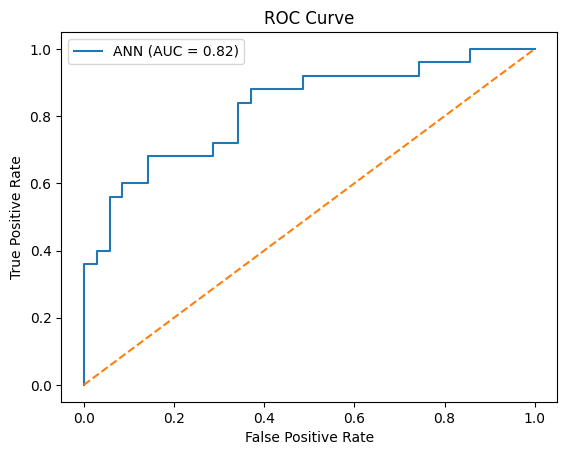

In [80]:
from sklearn.metrics import roc_curve, auc

y_prob_ann = model.predict(X_test)

fpr, tpr, _ = roc_curve(y_test, y_prob_ann)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"ANN (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [51]:
y_pred_ann = (model.predict(X_test) > 0.5).astype("int32")

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_ann))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
              precision    recall  f1-score   support

           0       0.78      0.83      0.81        35
           1       0.74      0.68      0.71        25

    accuracy                           0.77        60
   macro avg       0.76      0.75      0.76        60
weighted avg       0.77      0.77      0.77        60



In [52]:
from sklearn.utils import class_weight
import numpy as np

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    0: weights[0],
    1: weights[1]
}

In [78]:
print("ANN Accuracy",acc)
print("SVM Accuracy",accuracy_score(y_test, y_pred_svm))

ANN Accuracy 0.7666666507720947
SVM Accuracy 0.7


 ## 8. Model Comparison

- ANN achieved the highest accuracy
- ANN also performed better in identifying high-risk patients
- SVM and Random Forest performed slightly lower

In [57]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [59]:
from sklearn.metrics import classification_report, accuracy_score

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

RF Accuracy: 0.75
              precision    recall  f1-score   support

           0       0.73      0.91      0.81        35
           1       0.81      0.52      0.63        25

    accuracy                           0.75        60
   macro avg       0.77      0.72      0.72        60
weighted avg       0.76      0.75      0.74        60



In [81]:
import pandas as pd

importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df)

                     Feature  Importance
11                      time    0.394858
7           serum_creatinine    0.171368
4          ejection_fraction    0.113986
0                        age    0.087570
2   creatinine_phosphokinase    0.069107
8               serum_sodium    0.061386
6                  platelets    0.055653
1                    anaemia    0.010456
3                   diabetes    0.009917
9                        sex    0.009278
5        high_blood_pressure    0.008360
10                   smoking    0.008061


In [84]:
def predict_heart_failure(input_data):

    # Convert to DataFrame with correct feature names
    input_df = pd.DataFrame([input_data], columns=X.columns)

    # Scale
    input_scaled = scaler.transform(input_df)

    # Predict
    prediction = model.predict(input_scaled)

    if prediction > 0.5:
        return "High Risk of Heart Failure"
    else:
        return "Low Risk"

In [87]:
sample = X.iloc[0].values
print(predict_heart_failure(sample))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
High Risk of Heart Failure


## 9. Conclusion

- ANN performed best among all models
- Recall was prioritized due to medical importance
- Class imbalance handled using class weights

### Important Note:

In medical applications, recall is more important than accuracy because missing a high-risk patient can be dangerous.